---
# Parte I: Variables Aleatorias Discretas
---


# Variables aleatorias discretas


Para más información de las distribuciones discretas y continuas, [VER](https://docs.scipy.org/doc/scipy/reference/stats.html)


In [1]:
# numpy: arreglos, operaciones vectorizadas y generación de aleatorios
import numpy as np

# matplotlib.pyplot: graficación al estilo MATLAB; plt es el alias estándar
import matplotlib.pyplot as plt

# scipy.stats: colección de distribuciones estadísticas y pruebas de hipótesis
import scipy.stats as sps

# Importamos cada distribución que usaremos a lo largo del notebook
from scipy.stats import bernoulli, binom, poisson, geom, hypergeom

## Variable aleatoria uniforme discreta

Una variable aleatoria $X$ tiene distribución uniforme discreta en el conjunto $\{x_{1},\dots,x_{n}\}$ si su función de masa de probabilidades está dada por

$$
f_{X}(k)=\mathbb{P}(X=k)=\begin{cases}
\frac{1}{n} &\quad \text{si } k\in\{x_{1},\dots,x_{n}\} \\
0 &\quad \text{en otro caso}
\end{cases}
$$

**Notación:** $X\sim Unif(x_{1},\dots,x_{n}).$

Se llama uniforme porque cada uno de los posibles valores de $X$ tienen la misma probabilidad.

Si $X\sim Unif(x_{1},\dots,x_{n})$, en este caso, se tiene:
$$\mathbb{E}[X] = \sum_{k}kf_{X}(k)=\frac{x_n + x_1}{2}.$$
y
$$\text{Var}(X) = \mathbb{E}[(X-\mathbb{E}[X])^{2}] =\sum_{k}(k-\mathbb{E}[X])^{2}f_{X}(k)=\frac{(x_n - x_1+1)^2-1}{12}$$


**Ejemplo** Se lleva a cabo una rifa donde los boletos están enumerados del $00$ al $99$. Si $Y$ es la variable aleatoria definida como el número del boleto ganador, entonces:

$$
\mathbb{P}(Y=k)=\begin{cases}
	\frac{1}{100} &\quad \text{si } k=00,01,\dots,99 \\
	0 &\quad \text{en otro caso}
\end{cases}
$$

Consideremos que el premio de la rifa se determina a partir del número premiado de la siguiente forma: $X=Y+1$, donde $X$ es el monto del premio en pesos y $Y$ es el número premiado, entonces $X$ es una variable aleatoria, pues es una función de $Y$, y además se tiene

$$
f_{X}(k)=\begin{cases}
		\frac{1}{100} &\quad \text{si } x=1,2,\dots,100 \\
		0 &\quad \text{en otro caso}
	\end{cases}
$$

Entonces, la esperanza y varianza de $X$ están dados por:
$$\mathbb{E}[X] = \sum_{k=1}^{100}k\left(\frac{1}{100}\right) = \frac{1}{100}\sum_{k=1}^{100}k = \frac{1}{100}\left[\frac{100(100+1)}{2}\right] = 50.5$$
y
$$\text{Var}(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \sum_{k=1}^{100}k^{2}\left(\frac{1}{100}\right)-(50.5)^{2} = 833.25$$

Supongamos que nos interesa calcular la probabilidad de que el premio sea mayor a $\$80$, entonces
$$\mathbb{P}(X>80) = \sum_{k=81}^{100}\frac{1}{100} = \frac{20}{100} = 0.2$$
Su función de distribución esta dada por:

$$
F_{X}(x)=\mathbb{P}(X\le x)=\begin{cases}
		0 &\quad \text{si } x<1 \\
		\frac{x}{100} &\quad \text{si } x=1,2,\dots,100\\ 1 &\quad \text{si } x>100
	\end{cases}
$$


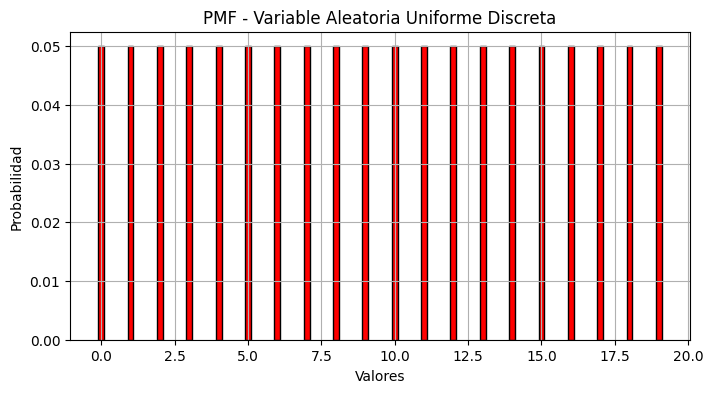

In [2]:
# - Distribución Uniforme Discreta -
min_val = 0
max_val = 20
x = np.arange(min_val, max_val)         # valores posibles: 0, 1, ..., 19

# Cada valor tiene la misma probabilidad: 1/(max-min)
pmf_unif = np.full_like(x, 1/(max_val - min_val), dtype=float)

plt.figure(figsize=(8, 4))
plt.bar(x, pmf_unif, width=0.2, color='r', edgecolor='black')  # barras estrechas
plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('PMF - Variable Aleatoria Uniforme Discreta')
plt.grid(True)
plt.show()

## Variable aleatoria Bernoulli con parámetro $p\in (0,1)$.

El modelo probabilístico Bernoulli se aplica a un experimento cuyo espacio muestral está constituido sólo por dos resultados posibles, éxito y fracaso:

Se considerará una v.a $X$ sobre el espacio muestral $$\Omega=\{\text{éxito, fracaso}\}$$
de tal forma que

- $X(\{\text{éxito}\}) = 1$
- $X(\{\text{fracaso}\}) = 0$

Las probabilidades asociadas a este modelo son:

- $\mathbb{P}(\{\text{éxito}\}) = p$
- $\mathbb{P}(\{\text{fracaso}\}) = 1-p$

donde $0<p<1$.

Entonces la función de densidad de masa de probabilidades de $X$ está dada por:

$$
f_{X}(k)=\begin{cases}
p &\quad \text{si } k=1 \\
1-p &\quad \text{si } k=0
\end{cases}
$$

**Notación:** $X\sim \text{Ber}(p)$.

Esta variable aleatoria es muy importante. En la practica es usada para modelar situaciones en las cuales hay dos posibles resultados como:

- el estado de un teléfono en un momento dado: libre u ocupado.
- una persona pueda estar enferma o sana de una determinada enfermedad.
- la preferencia de una persona, la cual puede estar a favor o en contra de un candidato determinado.

Mediante la combinación de variables aleatorias Bernoulli es posible construir otras variables aleatorias.

### Esperanza y Varianza

Si $X\sim \text{Ber}(p)$, entonces su esperanza es:
\begin{align*}
\mathbb{E}[X] = \sum*{k=0}^{1}kf*{X}(k) = 1\cdot p + 0\cdot (1-p) = p.
\end{align*}

Y su varianza se calcula usando,
$$\mathbb{E}[X^{2}] = \sum_{k=0}^{1}k^{2}f_{X}(k) = 1^{2}\cdot p + 0^{2}\cdot (1-p) = p.$$
Por lo tanto,
$$\text{Var}(X)=\mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = p-p^{2} = p(1-p)$$


PMF Bernoulli: [0.2 0.8]


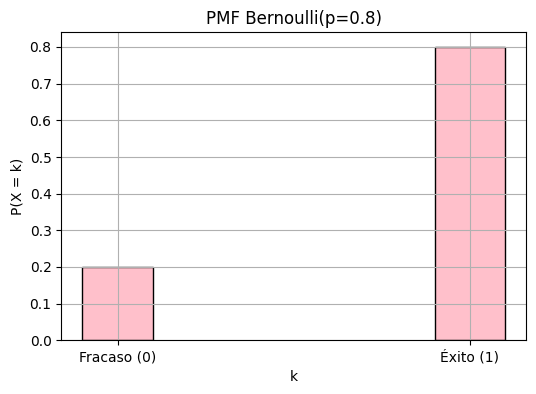

In [3]:
# - Distribución Bernoulli -
p = 0.8            # probabilidad de éxito
x = [0, 1]         # únicos valores posibles: fracaso (0) o éxito (1)

# bernoulli.pmf(k, p): P(X=k) para una Bernoulli con parámetro p
pmf_ber = bernoulli.pmf(x, p)
print('PMF Bernoulli:', pmf_ber)

plt.figure(figsize=(6, 4))
plt.bar(x, pmf_ber, width=0.2, color='pink', edgecolor='k')
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.title(f'PMF Bernoulli(p={p})')
plt.xticks([0, 1], ['Fracaso (0)', 'Éxito (1)'])
plt.grid(True)
plt.show()

In [4]:
# E[X] = p  y  Var(X) = p(1-p)  - calculados con scipy
media_ber = bernoulli.mean(p)     # equivale a p
var_ber   = bernoulli.var(p)      # equivale a p*(1-p)
print(f'E[X]    = {media_ber}')
print(f'Var(X)  = {var_ber}')

E[X]    = 0.8
Var(X)  = 0.15999999999999992


## Variable aleatoria Binomial con parámetros $n$ y $p\in (0,1)$.

Decimos que una v.a $X$ tiene distribución binomial con párametros $n$ y $p$, si su función de densidad de masa de probabilidades está dada por:

$$
\begin{equation*}
	f_{X}(k)=\begin{cases}
	\binom{n}{k}p^{k}(1-p)^{n-k} &\quad \text{si } k=0,1,\dots,n \\
	\qquad 0 &\quad \text{en otro caso}
	\end{cases}
\end{equation*}
$$

donde $n$ es un entero positivo y $0< p< 1$.

La esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&= \sum*{k \mathop = 0}^n k \binom n k p^k (1-p)^{n - k}\\
&=\sum*{k \mathop = 1}^n k \binom n k p^k (1-p)^{n - k}\\
&= \sum*{k \mathop = 1}^n n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum*{k \mathop = 1}^n \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{( {n - 1}) - ( {k - 1}) }\\
&=n p \sum\_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\\
&=np
\end{align*}

Ahora,
\begin{align*}
\mathbb{E}[X^2]&= \sum*{k \mathop = 0}^n k^2 \binom n k p^k (1-p)^{n - k}\\
&=\sum*{k \mathop = 0}^n k n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum*{k \mathop = 1}^n k \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{({n - 1}) - ({k - 1}) }\\
&= n p \sum*{j \mathop = 0}^m ({j + 1}) \binom m j p^j (1-p)^{m - j}\\
&=n p \left( {\sum*{j \mathop = 0}^m j \binom m j p^j (1-p)^{m - j} + \sum*{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&=n p \left( {\sum*{j \mathop = 0}^m m \binom {m - 1} {j - 1} p^j (1-p)^{m - j} + \sum*{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&= n p \left( (n - 1) p \sum*{j \mathop = 1}^m \binom {m - 1}{j - 1} p^{j - 1} (1-p)^{( {m - 1}) - ({j - 1}) } + \sum*{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\right) \\
&= n p \left( (n - 1) p (p + (1-p))^{m - 1} + (p + (1-p))^m\right)\\
&= n p ((n - 1) p + 1)\\
&= (np)^2 +np(1-p),
\end{align*}

por lo que la varianza de $X$ es:
$$\text{Var}(X)=np(1-p).$$


**Ejemplo** Una moneda no justa se tira 6 veces, donde la probabilidad de obtener sol es de $0.3$.

Sea $X$ el número de veces que cae sol, entonces $X$ tiene una distribución binomial con parámetros $n=6$ y $p=0.3$. Por lo que

$$
\begin{align*}
\mathbb{P}(X=2) &= \binom{6}{2}(0.3)^{2}(0.7)^{4}=0.3241 \\
\mathbb{P}(X=3) &= \binom{6}{3}(0.3)^{3}(0.7)^{3}=0.1852 \\
\mathbb{P}(1<X\le 5) &= \mathbb{P}(X=2)+\mathbb{P}(X=3)+\mathbb{P}(X=4)+\mathbb{P}(X=5) \\
			&= 0.3241 + 0.1852 + \binom{6}{4}(0.3)^{4}(0.7)^{2} + \binom{6}{5}(0.3)^{5}(0.7)^{1} \\
			&= 0.5093 + 0.0595 + 0.0102 = 0.579
\end{align*}
$$


Note que la probabilidad $$\mathbb{P}(1<X\leq 5)=F_{X}(5)-F_{X}(1).$$


Usando el tributo `.cdf `, podemos calcualr la probabilidad anterior:


In [5]:
# binom.cdf(k, n, p): P(X ≤ k) para X ~ Bin(n, p)
F5 = binom.cdf(5, 6, 0.3)   # P(X ≤ 5), con n=6, p=0.3
F1 = binom.cdf(1, 6, 0.3)   # P(X ≤ 1)
print(f'F(5) = {F5:.4f}')
print(f'F(1) = {F1:.4f}')

F(5) = 0.9993
F(1) = 0.4202


In [6]:
# P(1 < X ≤ 5) = F(5) - F(1)  (diferencia de acumuladas)
print(f'P(1 < X ≤ 5) = {F5 - F1:.4f}')

P(1 < X ≤ 5) = 0.5791


### Vamos a grafciar la función de densidad de una binomial


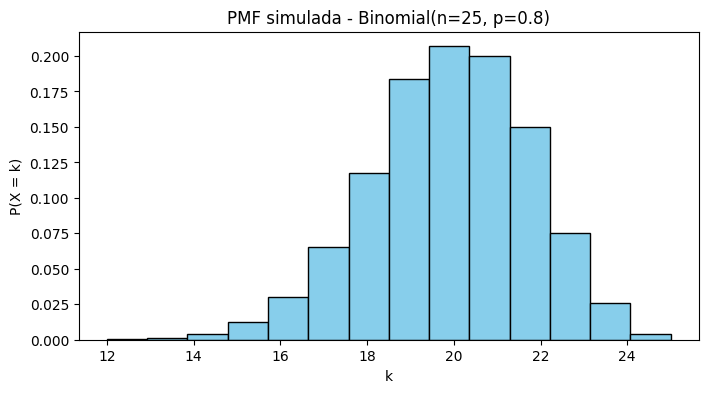

In [7]:
# - Histograma de una Binomial -
n = 25
p = 0.8

# sps.binom.rvs: genera n_samples números aleatorios con distribución Bin(n,p)
binom_nums = sps.binom.rvs(n, p, size=10000)

plt.figure(figsize=(8, 4))
plt.hist(
    binom_nums,
    density=True,                          # normaliza para que el área = 1
    bins=len(np.unique(binom_nums)),        # una barra por cada valor distinto
    color='skyblue',
    edgecolor='k'
)
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.title(f'PMF simulada - Binomial(n={n}, p={p})')
plt.show()

## Variable aleatoria Poisson

Es una distribución de probabilidad discreta que sirve para calcular la probabilidad de que ocurra un determinado **número de eventos raros** durante un intervalo dado (puede ser de tiempo, longitud, área, etc.

Esta variable aleatoria toma los valores sobre el conjunto $\{0,1,2,\dots\}$ y tiene un parámetro $\lambda>0$, el cual representa el número de veces que se **espera** que ocurra un evento durante un intervalo dado.

La función de masa de probabilidades de una variable aleatoria Poisson, $X$, está dada por:

$$
f_{X}(k)=\begin{cases}
	e^{-\lambda}\frac{\lambda^{k}}{k!} &\quad \text{si } k=0,1,2,\dots \\
	0 &\quad \text{en otro caso}
\end{cases}
$$

En efecto, es una función de masa de probabilidades debido a que

$$
\begin{align*}
\sum_{k=0}^{\infty}e^{-\lambda}\frac{\lambda^{k}}{k!} &= e^{-\lambda}\sum_{k=0}^{\infty}\frac{\lambda^{k}}{k!} \\ &= e^{-\lambda}\underbrace{\left(1+\lambda+\frac{\lambda^{2}}{2!}+\frac{\lambda^{3}}{3!}+\cdots\right)}_{\text{desarrollo de Taylor de }e^{\lambda}} \\ &= e^{-\lambda}e^{\lambda}=1.
\end{align*}
$$

Se tiene que $\mathbb{E}[X] = \lambda$ y $\text{Var}(X)= \lambda$.


**Aplicaciones**

**Ejemplo:** Supongamos que el número de accidentes que ocurre en un punto tiene una distribución Poisson con parámetro $\lambda=2$.

- ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes?

  $$
  \begin{align*}
  \mathbb{P}(X>2) &= 1-\mathbb{P}(X\le 2) \\ &=1-\left[\mathbb{P}(X=0)+\mathbb{P}(X=1)+\mathbb{P}(X=2)\right] \\ &= 1-\left[\frac{e^{-2}2^{0}}{0!}+\frac{e^{-2}2^{1}}{1!}+\frac{e^{-2}2^{2}}{2!}\right] \\ &= 1-e^{-2}\left[1+2+2\right] = 1-5e^{-2} = 0.3233
  \end{align*}
  $$

- ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes, sabiendo que ocurre por lo menos uno?
  $$
  \begin{align*}
  \mathbb{P}(X>2 \mid X\ge 1) = \frac{\mathbb{P}(X>2 \cap X\ge 1)}{\mathbb{P}(X\ge 1)} = \frac{\mathbb{P}(X>2)}{\mathbb{P}(X\ge 1)} = \frac{1-\mathbb{P}(X\leq 2)}{1-\mathbb{P}(X<1)} = \frac{1-5e^{-2}}{1-e^{-2}} = \frac{0.3233}{0.8646} = 0.3739
  \end{align*}
  $$
  ya que $\mathbb{P}(X\ge 1)=1-\mathbb{P}(X<1)=1-\mathbb{P}(X=0)=1-e^{-2}$


Ahora, vamos a calcular las probabilidades anteriores usando el atributo `.cdf`


In [8]:
# - Cálculo de probabilidades Poisson -
lamb = 2   # λ = tasa esperada de accidentes por día

# P(X > 2) = 1 - P(X ≤ 2) = 1 - F(2)
prob_mas2 = 1 - poisson.cdf(2, lamb)
print(f'P(X > 2)        = {prob_mas2:.4f}')

# P(X > 2 | X ≥ 1) = P(X > 2) / P(X ≥ 1)  (probabilidad condicional)
prob_cond = prob_mas2 / (1 - poisson.cdf(0, lamb))
print(f'P(X>2 | X≥1)    = {prob_cond:.4f}')

P(X > 2)        = 0.3233
P(X>2 | X≥1)    = 0.3739


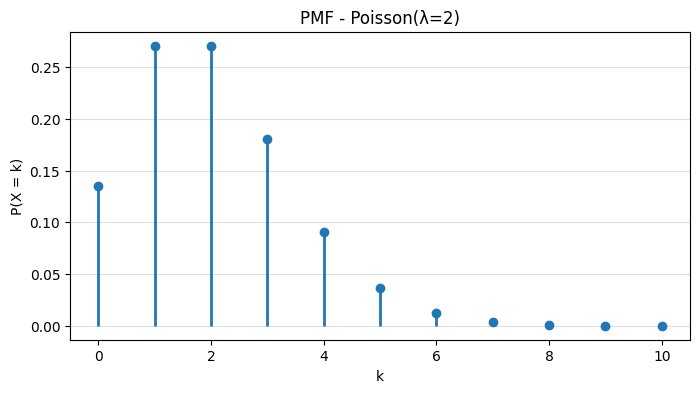

In [9]:
# - Gráfica de la densidad Poisson -
x_poi = np.arange(0, 11)               # valores 0, 1, ..., 10
y_poi = poisson.pmf(x_poi, lamb)       # P(X = k) para cada k

plt.figure(figsize=(8, 4))
plt.vlines(x_poi, 0, y_poi, linewidth=2)   # líneas verticales desde 0 hasta P(k)
plt.plot(x_poi, y_poi, 'o', markersize=6)  # puntos sobre cada probabilidad
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.title(f'PMF - Poisson(λ={lamb})')
plt.grid(axis='y', alpha=0.4)
plt.show()

## Aproximación de Poisson a la Binomial

La distribución de Poisson es una forma límite de la distribución binomial, es decir, es una buena aproximación cuando $n$ es suficientemente grande y $p$ suficientemente pequeña.

$\textbf{Teorema (Poisson).-}$ Sean $S_{n}\sim Bin(n,p_{n})$ bajo el regimen $$\lim_{n\to \infty}np_{n}=\lambda>0.$$
Consideremos la siguiente sucesión de números reales:

$$
a_{j}(n,p_n)=\begin{cases}\binom{n}{j}(p_n)^{j}(1-p_{n})^{n-j} & j\leq n\\
0 & j\geq n+1\end{cases}
$$

Entonces,
$$\lim_{n\to \infty}a_{j}(n,p_n)=a_{j}=e^{-\lambda}\frac{\lambda^{j}}{j!} \ \ \forall j\in \mathbb{N}.$$

El teorema anterior implica que la distribución de Poisson ofrece un modelo probabilístico adecuado para todos aquellos experimentos aleatorios en los que las repeticiones son independientes unas de otras y en los que sólo hay dos posibles resultados: éxito o fracaso, con probabilidad de éxito pequeña, y en los que el interés se centra en conocer el número de éxitos obtenidos al realizar el experimento un número suficientemente grande de veces.

Empíricamente se ha establecido, que la aproximación se puede aplicar con seguridad si $n\ge100$, $p\le 0.01$ y $np \le20$.

**Ejemplo** Supongamos que la probabilidad de que un producto producido por cierta máquina es defectuoso es de $0.1$. ¿Cuál es la probabilidad de que un lote de 10 productos contenga a lo más un producto defectuoso?

Sea $X$ el número de productos defectuosos, y sabemos que $X$ tiene una distribución binomial con parámetros $n=10$ y $p=0.1$, entonces
\begin{align*}
\mathbb{P}(X\le 1) &= \mathbb{P}(X=0)+\mathbb{P}(X=1) \\ &= \binom{10}{0}(0.1)^{0}(0.9)^{10-0}+\binom{10}{1}(0.1)^{1}(0.9)^{10-1} \\ &= 0.7361
\end{align*}

Ahora, con la distribución Poisson, tenemos que $\lambda=10(0.1)=1$, por lo que
$$\mathbb{P}(X\le 1) = \mathbb{P}(X=0)+\mathbb{P}(X=1) = \frac{e^{-1}1^{0}}{0!}+\frac{e^{-1}1^{1}}{1!} = e^{-1}+e^{-1} =0.7358$$


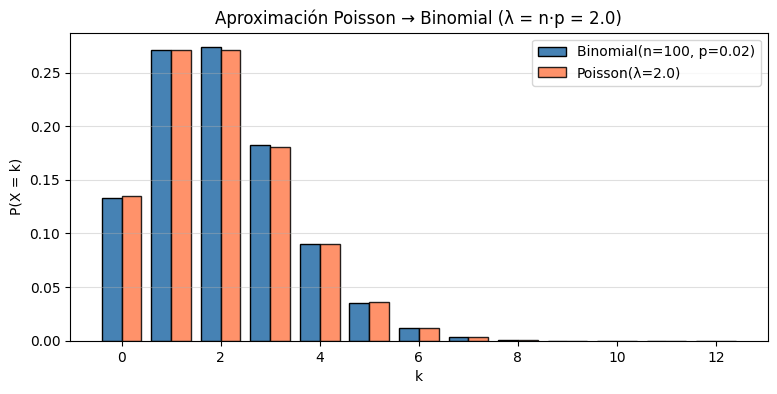

In [10]:
# - Comparación visual: Binomial vs. Poisson -
# Régimen: n grande, p pequeña, λ = n·p fijo
n_ap, p_ap = 100, 0.02     # n=100, p=0.02
lam_ap = n_ap * p_ap        # λ = 2  (mismo que el ejemplo de accidentes)

x_ap = np.arange(0, 13)
pmf_bin_ap = binom.pmf(x_ap, n_ap, p_ap)   # distribución original
pmf_poi_ap = poisson.pmf(x_ap, lam_ap)      # aproximación Poisson

plt.figure(figsize=(9, 4))
# Barras desplazadas para comparar lado a lado
plt.bar(x_ap - 0.2, pmf_bin_ap, width=0.4,
        label=f'Binomial(n={n_ap}, p={p_ap})', color='steelblue', edgecolor='k')
plt.bar(x_ap + 0.2, pmf_poi_ap, width=0.4,
        label=f'Poisson(λ={lam_ap})', color='coral', edgecolor='k', alpha=0.85)
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.title(f'Aproximación Poisson → Binomial (λ = n·p = {lam_ap})')
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.show()

## Variable aleatoria Geométrica con parámetro $p\in (0,1)$.

Esta variable aleatoria cuenta el número de fracasos antes del primer éxito en ensayos bernoulli independientes con parámetro $0<p<1$, y su función de masa de probabilidades está dada por:

$$
f_{X}(k)=\begin{cases}
	p(1-p)^{k-1} &\quad \text{si } k=1,2,\dots \\
	\qquad 0 &\quad \text{en otro caso}
\end{cases}
$$

Notación. $X\sim Geo(p)$

La cual es una función de densidad ya que:

- $0\le f_{X}(k)\le 1$ para toda $x$.
- $$
  \begin{align*}
  \sum_{k\in R_{X}}f_{X}(k) &= \sum_{k=1}^{\infty}(1-p)^{k-1}p \\
  		&= p\sum_{y=0}^{\infty}(1-p)^{y} \\
  		&= p\left(\frac{1}{1-(1-p)}\right) = 1
  	\end{align*}
  $$

Si por el contrario queremos contar el número de éxitos antes del primer fracaso, tenemos que la función de está dada por:

$$
f_{X}(k)=\begin{cases}
		p^{k}(1-p) &\quad \text{si } k=0,1,2,\dots \\
		\qquad 0 &\quad \text{en otro caso}
	\end{cases}
$$

Para calcular la Esperanza y Varianza de $X$, necesitamos del siguiente lema:

**Lema 1** Sea $x$ un número real tal que $│x│<1$. Entonces,
$$\sum_{k=1}^{\infty}kx^{k-1}=\frac{1}{(1-x)^2}.$$
**Demostración.** Se tiene que
$$\frac{d}{dx}\sum_{k=1}^{\infty}x^{k}=\sum_{k=1}^{\infty}kx^{k-1}.$$
Además,
$$\sum_{k=1}^{\infty}x^{k}=\frac{x}{1-x}.$$
Por lo tanto,
$$\frac{d}{dx}\frac{x}{1-x}=\frac{1}{(1-x)^2}.$$

Como corolario,
$$\sum_{k=1}^{\infty}k(k+1)x^{k-1}=\frac{2}{(1-x)^2}.$$
En efecto,
$$\frac{d}{dx}\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{k=1}^{\infty}k(k+1)x^{k-1}.$$
Ahora,
$$\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{m=2}^{\infty}mx^{m-1}=\frac{1}{(1-x)^2}-1.$$

Usando estos resultados, la esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&= \sum\_{x \mathop \ge 1} k p(1-p)^{k - 1}\\
&= p \frac 1 {(1 - (1-p))^2}\\
&= \frac p {p^2}\\
&=\frac{1}{p}
\end{align*}

Calculamos,
\begin{align*}
\mathbb{E}[X^2]&= \sum*{k=1}^{\infty} x^{2}p(1-p)^{k-1}\\
&=\sum*{k=1}^{\infty}k(k+1)(1-p)^{k-1}p-\sum\_{k=1}^{\infty}p(1-p)^{k-1}
\end{align*}

Por el Lema 1,
$$\mathbb{E}[X^2]=p\frac{2}{p^3}-\frac{1}{p}=\frac{2}{p^2}-\frac{1}{p}.$$

Por lo tanto,
$$\text{Var}(X)=\frac{2}{p^2}-\frac{1}{p}-\frac{1}{p^2}=\frac{1-p}{p^2}.$$


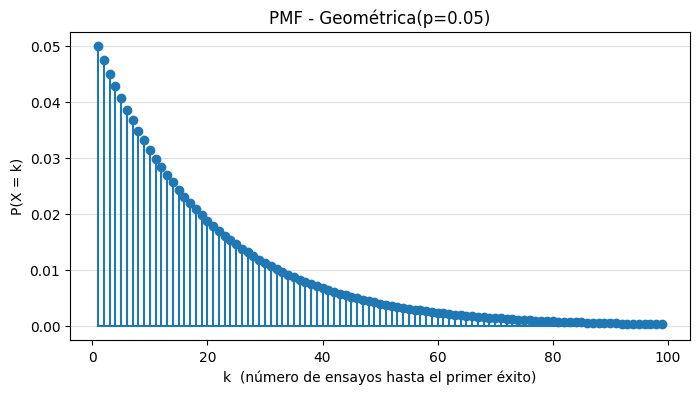

In [11]:
# - Gráfica de la distribución Geométrica -
p_geo = 0.05                       # probabilidad de éxito en cada ensayo
x_geo = np.arange(1, 100)          # valores posibles: 1, 2, ..., 99

# geom.pmf(k, p): P(X=k) = p·(1-p)^(k-1)
pmf_geo = geom.pmf(x_geo, p_geo)

plt.figure(figsize=(8, 4))
plt.stem(x_geo, pmf_geo, basefmt='')   # gráfica de tallos para valores discretos
plt.xlabel('k  (número de ensayos hasta el primer éxito)')
plt.ylabel('P(X = k)')
plt.title(f'PMF - Geométrica(p={p_geo})')
plt.grid(axis='y', alpha=0.4)
plt.show()

# Variable Aleatoria Binomial Negativa $X \sim \text{BN}(r, p)$

La distribución **Binomial Negativa** describe procesos donde el número de éxitos está predeterminado ($r$), y nuestra incertidumbre recae sobre cuántos intentos totales ($X$) necesitaremos realizar para alcanzar dicha meta.

Supongamos que se realizan ensayos independientes, cada uno con probabilidad $0<p<1$ de ser un éxito, hasta obtener un total de $r$ éxitos acumulados. Sea $X$ el número de ensayos que se requieren, entonces la probabilidad de que el éxito número $r$ ocurra exactamente en el ensayo $k$ es:

$$f_{X}(k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}$$

Donde:

- El valor de $k$ pertenece al conjunto $\{r, r+1, r+2, \dots\}$.
- El parámetro de Forma ($r$): representa el número de éxitos acumulados que deseamos obtener ($r \geq 1$).
- El parámetro de Intensidad ($p$): es la probabilidad de éxito en cada ensayo independiente ($0 < p < 1$).

El valor promedio esperado de ensayos totales es:
$$\mathbb{E}[X] = \frac{r}{p}$$
Y la varianza mide la dispersión de los ensayos necesarios:
$$\text{Var}[X] = \frac{r(1-p)}{p^2}$$


## Aplicaciones en Ciencia de Datos y Estadística

### 1. Control de Calidad y Procesos Industriales

Imagina que eres un ingeniero en una fábrica y necesitas recolectar **10 piezas defectuosas** $r = 10$ para analizar por qué fallan. Si sabes que la probabilidad de que una pieza salga mal es $p = 0.01 $:

- **¿Para qué sirve?** Para calcular cuántas piezas totales tendrás que inspeccionar en promedio antes de completar tu muestra.

- **Cálculo:** $$\mathbb{E}[X] = 10 / 0.01 = 1{,}000 $$ piezas. Esto te ayuda a presupuestar el tiempo de inspección.

### 2. Estrategias de Marketing y Ventas

Un vendedor necesita cerrar **5 ventas** $r = 5$ para llegar a su cuota diaria. Por experiencia, sabe que tiene una probabilidad de éxito del 20%, es decir, $p = 0.2$ por cada llamada.

- **¿Para qué sirve?** Para determinar cuántas llamadas debe hacer. El modelo le dirá que en promedio hará 25 llamadas, pero la **Varianza** le advertirá que hay días "malos" donde podría necesitar 40 o 50 llamadas para lograr el mismo objetivo.

### 3. Epidemiología y Salud Pública

Se usa para modelar el número de personas expuestas a un virus hasta que se encuentran $r$ casos positivos.

- **¿Para qué sirve?** Ayuda a entender la propagación de enfermedades. Si el virus es muy contagioso ($p$ alta), llegaremos a los $r$ casos rápido. Si la varianza es alta, la enfermedad es impredecible ("super-propagadores").

### 4. Modelado de "Sobredispersión" (Uso Avanzado)

En estadística de datos (Data Science), muchas veces usamos la **Binomial Negativa** cuando la **Distribución de Poisson** falla.

- En Poisson, la media es igual a la varianza.

- En la vida real (como clics en un anuncio o llegadas de clientes), la varianza suele ser mucho mayor que la media. La Binomial Negativa permite ajustar modelos donde los datos están muy dispersos.

### 5. Modelado de Tiempos de Espera

Se usa para predecir cuándo se completará una muestra de datos (ej. "necesitamos 100 encuestas válidas, ¿cuánta gente debemos contactar?").


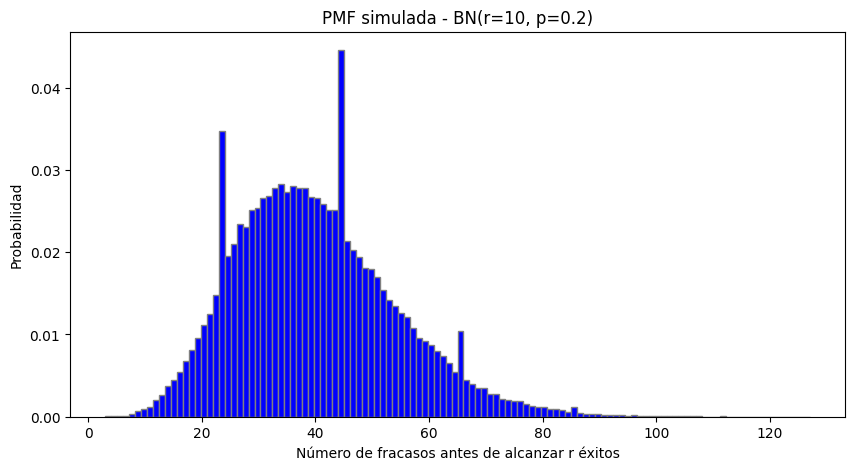

In [12]:
# - Histograma de la Binomial Negativa -
r   = 10       # número de éxitos deseados
p_bn = 0.2     # probabilidad de éxito por ensayo
s   = 100000   # número de muestras para la simulación

np.random.seed(3)  # semilla para reproducibilidad
# sps.nbinom.rvs devuelve el número de FRACASOS antes de r éxitos
nbinom_nums = sps.nbinom.rvs(r, p_bn, size=s)

plt.figure(figsize=(10, 5))
plt.hist(
    nbinom_nums,
    density=True,                          # normaliza el área a 1
    bins=len(np.unique(nbinom_nums)),       # una barra por valor
    color='blue', edgecolor='grey'
)
plt.xlabel('Número de fracasos antes de alcanzar r éxitos')
plt.ylabel('Probabilidad')
plt.title(f'PMF simulada - BN(r={r}, p={p_bn})')
plt.show()

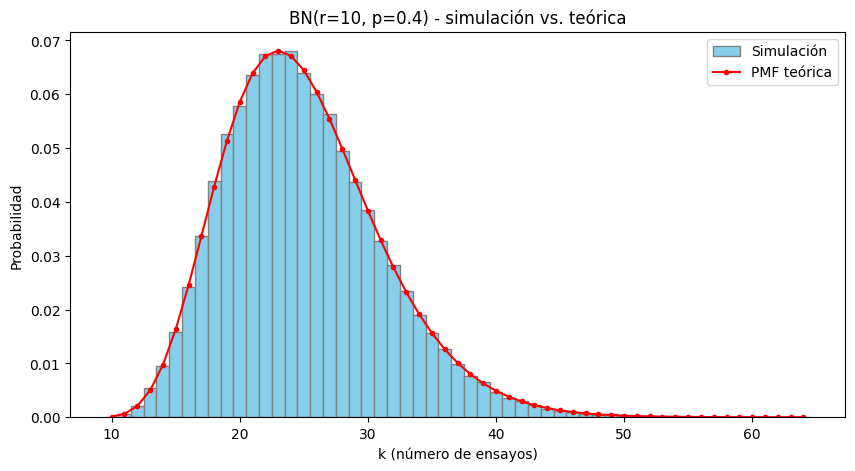

In [13]:
# - BN: simulación de ensayos totales vs. PMF teórica -
r2, p2 = 10, 0.4
s2 = 100000
np.random.seed(3)

# nbinom en scipy cuenta fracasos; sumamos r para obtener ensayos totales
nbinom_fracasos = sps.nbinom.rvs(r2, p2, size=s2)
nbinom_ensayos  = nbinom_fracasos + r2      # total de ensayos = fracasos + éxitos

x_teo = np.arange(r2, np.max(nbinom_ensayos))
# pmf teórica: pasamos fracasos = x_teo - r2
pmf_teo = sps.nbinom.pmf(x_teo - r2, r2, p2)

plt.figure(figsize=(10, 5))
plt.hist(nbinom_ensayos, density=True,
         bins=np.arange(r2, np.max(nbinom_ensayos)+1) - 0.5,
         color='skyblue', edgecolor='grey', label='Simulación')
plt.plot(x_teo, pmf_teo, 'ro-', markersize=3, label='PMF teórica')  # superponemos la teórica
plt.xlabel('k (número de ensayos)')
plt.ylabel('Probabilidad')
plt.title(f'BN(r={r2}, p={p2}) - simulación vs. teórica')
plt.legend()
plt.show()

## Variable aleatoria Hipergeométrica con parámetros $n,N,m$.

Supongamos que se elige, **sin reemplazo**, una muestra de tamaño $n$ de una urna que contiene $N$ bolas, de las cuales $m$ son rojas y $N-m$ son verdes. Sea $X$ el número de bolas rojas seleccionadas, entonces su función de masa de probabilidades está dada por:

$$
f_{X}(i)=
	\frac{\binom{m}{i}\binom{N-m}{n-i}}{\binom{N}{n}} \quad \text{si } i=0,1,\dots, n
$$

Donde

- Los valores posibles de $X$ son
  $$ i=\max\{0,n-(N-m)\},\dots,\min\{n,m\}. $$

Notación. $X\sim \text{Hiper}(n,N,m)$.

Se tiene que
$$\mathbb{E}[X]=\frac{nm}{N}$$
y
$$\text{Var}[X]=\frac{nm}{N}\left[\frac{(n-1)(m-1)}{N-1}+1-\frac{nm}{N} \right].$$

Equivalentemente,

$$
\mathrm{Var}(X)=n\frac{m}{N}\left(1-\frac{m}{N}\right)\frac{N-n}{N-1}.
$$

**Nota.** Si $i\leq n$ y $X\sim \text{Hiper}(n,N,m)$, con $p=\frac{m}{N}$ y $m,N$ son muy grandes con respecto a $n$ e $i$, entonces
$$\mathbb{P}(X=i)\approx \binom{n}{i}p^{i}(1-p)^{n-i}.$$

Es decir, en poblaciones muy grandes, la distribución hipergeométrica puede aproximarse por una distribución binomial.


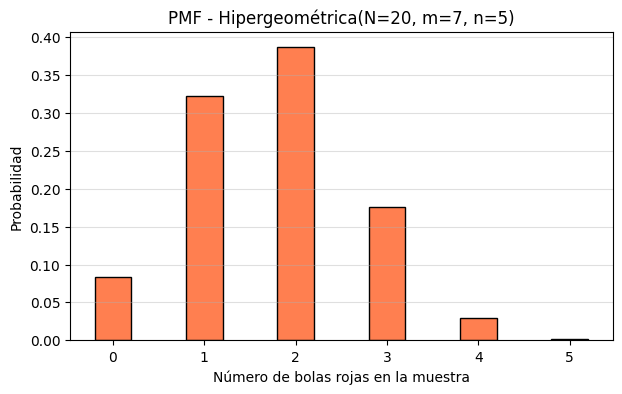

E[X]   = 1.7500  (teórico: 1.7500)
Var(X) = 0.8980


In [14]:
# - Gráfica y cálculo de la Hipergeométrica -
# Parámetros de la urna
N_hip = 20   # total de bolas en la urna
m_hip = 7    # bolas rojas (de interés)
n_hip = 5    # tamaño de la muestra extraída sin reemplazo

# Valores posibles de X: de max(0, n-(N-m)) a min(n, m)
x_hip = np.arange(max(0, n_hip-(N_hip-m_hip)), min(n_hip, m_hip)+1)

# hypergeom.pmf(k, M, n, N): P(X=k) con urna de M bolas, n rojas, muestra N
pmf_hip = hypergeom.pmf(x_hip, N_hip, m_hip, n_hip)

plt.figure(figsize=(7, 4))
plt.bar(x_hip, pmf_hip, width=0.4, color='coral', edgecolor='k')
plt.xlabel('Número de bolas rojas en la muestra')
plt.ylabel('Probabilidad')
plt.title(f'PMF - Hipergeométrica(N={N_hip}, m={m_hip}, n={n_hip})')
plt.xticks(x_hip)
plt.grid(axis='y', alpha=0.4)
plt.show()

# E[X] = n·m/N   y   Var(X) según la fórmula
print(f'E[X]   = {hypergeom.mean(N_hip, m_hip, n_hip):.4f}  '
      f'(teórico: {n_hip*m_hip/N_hip:.4f})')
print(f'Var(X) = {hypergeom.var(N_hip, m_hip, n_hip):.4f}')

---
# Parte II: Variables Aleatorias Continuas
---


# Variables aleatorias (absolutamente) continuas


## Variable aleatoria exponencial con parámetro $\lambda >0$.

La distribución exponencial es una de las distribuciones continuas más utilizadas. A menudo se utiliza para modelar el tiempo transcurrido entre eventos.

Algunos ejemplos en los que podría utilizarse la distribución exponencial son:

- El tiempo transcurrido en un call center hasta recibir la primer llamada del día.
- El tiempo entre terremotos de una determinada magnitud.
- Supongamos una máquina que produce hilo de alambre, la cantidad de metros de alambre hasta encontrar una falla en el alambre se podría modelar como una exponencial.

Se dice que la variable aleatoria $X$ tiene distribución exponecial de parámetro $\lambda>0$, si su función de densidad está dada por:

$$
f_{X}(x)=\begin{cases}
\lambda e^{-\lambda x} & x>0\\
0 & \text{en otro caso}
\end{cases}
$$

Notación. $X\sim \exp(\lambda).$

$\textbf{Propiedad de pérdida de memoria:}$
$$\mathbb{P}(X>t+s \mid X>t)=\mathbb{P}(X>s)=e^{-\lambda s}.$$

La esperanza y varianza de de una distribución exponencial de la forma $$f_{X}(x)=\begin{cases}
\frac{1}{\lambda} e^{-\frac{x}{\lambda}} & x>0\\
0 & \text{en otro caso}
\end{cases}$$:
$$\mathbb{E}[X]= \int_{0}^{\infty}xf_{x}(x)dx = \int_{0}^{\infty}x\frac{1}{\lambda}e^{-\frac{x}{\lambda}}dx = \lambda$$
y
\begin{align*}
\text{Var}(X) &= \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \int*{0}^{\infty}x^{2}f*{x}(x)dx-\lambda^{2} \\ &= \int\_{0}^{\infty}x^{2}\frac{1}{\lambda}e^{-\frac{x}{\lambda}}dx - \lambda^{2} = \lambda^{2}
\end{align*}

Se tiene que la función de distribución de la v.a. exponencial:

$$ F*{X}(x) = \mathbb{P}(X\le x) = \int*{0}^{x}\lambda e^{-\lambda u} du = 1- e^{-\lambda x}$$


**Ejemplo**

Consideremos la variable aleatoria $X$ como el tiempo (en minutos) entre la llegada de dos personas a la fila de una sucuarsal bancaria.

Adicionalmente, el banco ha determinado que solo el $10\%$ de las veces, el tiempo que transcurre entre la llegada de una persona y otra es mayor a dos minutos.

Esto permite calcular el valor de $\lambda$, ya que
$$\mathbb{P}(X>2)=0.1$$
entonces
$$1-\mathbb{P}(X\le 2) = 1-F_{X}(2) = 0.1$$

Notemos que si $X\sim Exp\left( \lambda \right)$, entonces
$$F_{X}(x) = 1-e^{-\frac{x}{\lambda}} $$

Por lo que $F_{X}(2)= 1-e^{\frac{-2}{\lambda}} =0.9$, entonces
$e^{\frac{-2}{\lambda}}=0.1$. Por lo que
$$\frac{-2}{\lambda}=\ln(0.1) \Rightarrow \lambda=0.87$$
Por lo tanto $X\sim\exp(0.87)$.

Ahora queremos calcular la probabilidad de que entre la llegada de una persona y otra transcurra por lo menos un minuto, lo cual puede calcularse de dos formas:

\begin{align*}
\mathbb{P}(X>1) &= \int*{1}^{\infty}f*{X}(x)dx = \int\_{1}^{\infty}\frac{1}{0.87}e^{\frac{-x}{0.87}}dx = 0.32
\end{align*}

\begin{align*}
\mathbb{P}(X>1) &= 1-\mathbb{P}(X\le 1) = 1-\left[1-e^{\frac{-1}{0.87}}\right] = e^{\frac{-1}{0.87}}
\end{align*}


P(X > 1 min) = 0.4190   (teórico: e^(-1/0.87) ≈ 0.32)


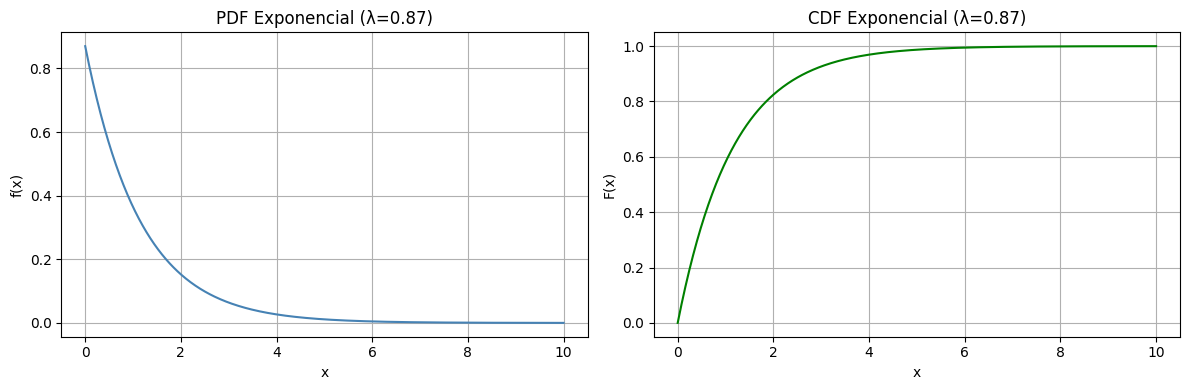

In [15]:
# - Cálculo de probabilidades - Distribución Exponencial -
from scipy.stats import expon

# Del ejemplo del banco: λ ≈ 0.87  →  scale = 1/λ en scipy
# (scipy usa la parametrización f(x) = (1/scale)·e^(-x/scale))
lamb_banco = 0.87
scale_banco = 1 / lamb_banco  # convertimos λ a scale

# P(X > 1): probabilidad de que pasen más de 1 minuto entre llegadas
prob_gt1 = 1 - expon.cdf(1, scale=scale_banco)
print(f'P(X > 1 min) = {prob_gt1:.4f}   (teórico: e^(-1/0.87) ≈ 0.32)')

# Gráfica de la PDF y CDF juntas
x_exp = np.linspace(0, 10, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x_exp, expon.pdf(x_exp, scale=scale_banco), color='steelblue')
ax1.set_title(f'PDF Exponencial (λ={lamb_banco})')
ax1.set_xlabel('x');  ax1.set_ylabel('f(x)');  ax1.grid(True)

ax2.plot(x_exp, expon.cdf(x_exp, scale=scale_banco), color='green')
ax2.set_title(f'CDF Exponencial (λ={lamb_banco})')
ax2.set_xlabel('x');  ax2.set_ylabel('F(x)');  ax2.grid(True)

plt.tight_layout()
plt.show()

Una propiedad interesante de la distribución exponencial es que puede verse como un análogo continuo de la distribución geométrica. Para ver esto, recuerde el experimento aleatorio detrás de la distribución geométrica: lanza una moneda (repite un experimento de Bernoulli) hasta que observa las primeras caras (éxito).

$\mathbf{Teorema.-}$ Sea $\varepsilon>0$ y $Y_{\epsilon}\sim Geo(p_{\varepsilon})$. Supongamos que nos encontramos en el regimen:
$$\lim_{\varepsilon\to 0}p_{\varepsilon}=0 \qquad \text{y} \qquad \varepsilon^{-1}p_{\varepsilon}\sim \lambda>0$$
Sea $X_{\varepsilon}:=\varepsilon Y_{\varepsilon}$. Entonces,
$$\lim_{\varepsilon\to 0}F_{X_{\varepsilon}}(x)=F_{X}(x),$$
en donde $X\sim \exp(\lambda)$. Este también es un resultado de convergencia en ley.


# Variable aleatoria normal con parámetros media $\mu$ y varianza $\sigma^{2}$.

La distribución normal es una de las más importantes y de mayor uso tanto en la teoría de la probabilidad, como en la teoría estadística.

También llamada distribución gaussiana, en honor a Gauss, a quien se considera el padre de ésta distribución.

La importancia de la distribución normal, radica en el famoso Teorema central del límite. Fue descubierta por De Moivre en 1733 como un límite de la distribución binomial.

La importancia de esta distribución radica en que permite modelar numerosos fenómenos naturales, sociales y psicológicos, por ejemplo:

- Estatura
- Efectos de un fármaco
- Consumo de cierto producto por un grupo de individuos
- Coeficiente intelectual
- Nivel de ruido en telecomunicaciones
- Errores cometidos al medir ciertas magnitudes

Además, esta distribución juega un papel de suma importancia en la inferencia estadística.

Se dice que la variable aleatoria $X$ tiene distribución normal de parámetros $\mu$ y $\sigma^{2}$, donde $\mu,\sigma\in\mathbb{R}$ y $\sigma>0$, si su función de densidad está dada por:

$$
f_{X}(x)=\begin{cases}
	\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-\mu)^{2}}{2\sigma^{2}}} &\quad \text{si }  x \in\mathbb{R} \\
	\qquad 0 &\quad \text{e.o.c}
\end{cases}
$$

**Notación.** $X\sim N(\mu,\sigma^{2})$

Tal curva (**la campana de Gauss-Bell**) es una función que depende de los parámetros $\mu$ y $\sigma^{2}$.

**Observación:** El parámetro $\mu$ se llama _media_ y el parámetro $\sigma^{2}$ se llama _varianza_.

La función de densidad definida anteriormente es efecto función de densidad, ya que
$$\int_{\mathbb{R}}f_{X}(x)dx = \int_{\mathbb{R}}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-m)^{2}}{2\sigma^{2}}}  = 1 $$

Variable aleatoria normal con parámetros 0 y 1 .
La ley de $Z\sim N(0,1)$ está dada por la función de densidad

$$
f_{Z}(z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}},
$$

para $z\in \mathbb{R}$.

Sabemos que:

- La varianza es usada como una medida para comparar la dispersión en dos o más conjuntos de observaciones.
- Una desviación estándar pequeña indica que los valores de la variable aleatoria se encuentran cercanos a la media.
- Una desviación estándar grande indica que los valores de la variable aleatoria se dispersan mucho con respecto a la media.

La función de distribución de una variable aleatoria $X\sim N(\mu,\sigma^{2})$ está dada por:
$$F_{X}(x) = \int_{-\infty}^{x}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(y-\mu)^{2}}{2\sigma^{2}}}dy$$

Esta nos proporciona la probabilidad de que $X$ tome calores menores o iguales a un valor específico $x$, y corresponde al área bajo la curva en el intervalo $(-\infty,x]$:

No es sencillo calcular $F_{X}(x)$, pero cualquier v.a. gaussiana puede transformarse a una v.a. estandarizada. Existen tablas para esta v.a., lo cual hace los cálculos más fáciles.

**Proposición** Sea $X\sim N(\mu,\sigma^{2})$, entonces
$$Z=\frac{X-\mu}{\sigma}$$
tiene una distribución gaussiana con media $0$ y varianza $1$, es decir, $Z\sim N(0,1)$.

**Demostración** Primero vamos a calcular la función de distribución de $Z$:
$$F_{Z}(z):=\mathbb{P}(Z\le z) = \mathbb{P}\left(\frac{X-\mu}{\sigma}\le z\right) = \mathbb{P}(X\le \sigma z + \mu) := F_{X}(\sigma z + \mu)$$
Entonces, la función de densidad de $Z$ esta dada por:
$$f_{Z}(z) = \frac{dF_{Z}(z)}{dz} = \frac{dF_{X}(\sigma z + \mu)}{dz} = \sigma f_{X}(\mu+\sigma z) = \frac{e^{-z^{2}/2}}{\sqrt{2\pi}}$$

Podemos calcular cualquier probabilidad de la forma
$$\mathbb{P}(a<X<b)$$
de la siguiente manera: para $z\ge 0$, definimos
$$\Phi(z) = \frac{1}{\sqrt{2\pi}}\int_{0}^{z}e^{-x^{2}/2}dx.$$


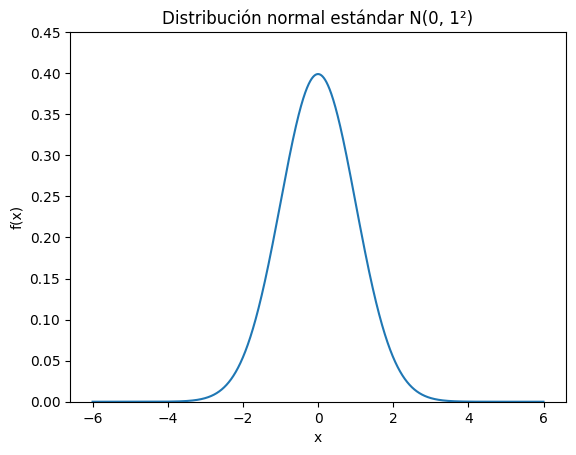

In [16]:
# - Distribución Normal Estándar N(0,1) -
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm   # norm(loc=μ, scale=σ) para N(μ, σ²)

fig, ax = plt.subplots()
x_nor = np.arange(-6, 6, 0.001)   # dominio: amplio rango simétrico

ax.plot(x_nor, norm.pdf(x_nor))    # norm.pdf sin argumentos = N(0,1)
ax.set_title('Distribución normal estándar N(0, 1²)')
ax.set_xlabel('x');  ax.set_ylabel('f(x)')
ax.set_ylim(0, 0.45)
plt.show()

Propiedades de la función de densidad de probabilidades de una distribución normal estándar:

1. Es positiva: $f(x)\geq 0$ para todo $x$ real.
2. Es continua y derivable en todas partes.
3. Es simétrica alrededor de $\mu$.
4. Conforme $x$ toma valores muy grandes de manera positiva y negativa, la función decrece hacia cero muy rápidamente.
5. Tiene un máximo global.
6. El área total bajo la curva es igual a $1$.


Veamos el comportamiento de la función conforme se cambia la varianza.


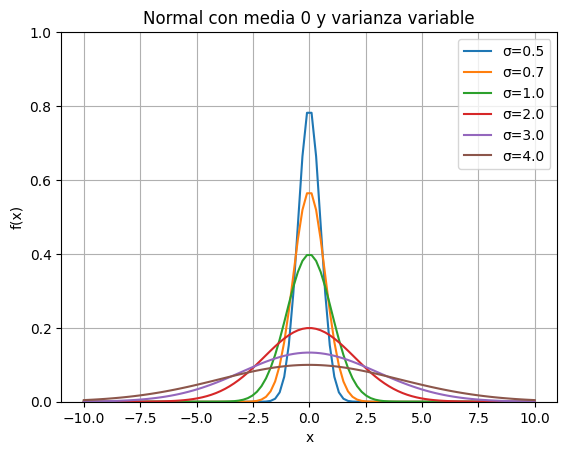

In [17]:
# - Efecto de la varianza σ² sobre la forma de la normal -
fig, ax = plt.subplots()
x_v = np.linspace(-10, 10, 100)          # dominio
stdvs = [0.5, 0.7, 1.0, 2.0, 3.0, 4.0]  # diferentes desviaciones estándar

for s in stdvs:
    # norm.pdf(x, scale=s): densidad con media=0 y desviación estándar=s
    ax.plot(x_v, norm.pdf(x_v, scale=s), label=f'σ={s}')

ax.set_xlabel('x');  ax.set_ylabel('f(x)')
ax.set_title('Normal con media 0 y varianza variable')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0, 1);  ax.grid(True)
plt.show()

Veamos el comportamiento de la función conforme se cambia la media.


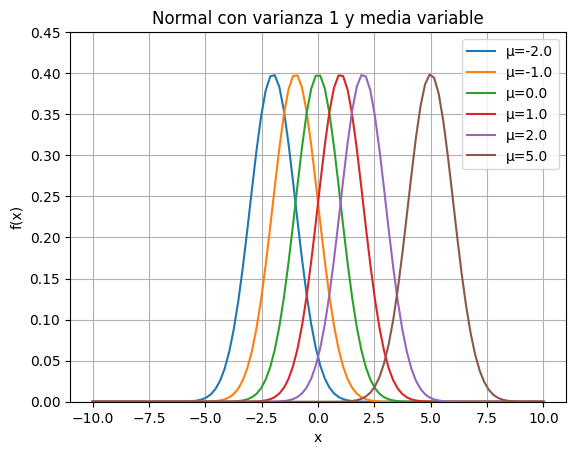

In [18]:
# - Efecto de la media μ sobre la posición de la normal -
fig, ax = plt.subplots()
x_m = np.linspace(-10, 10, 100)
means = [-2.0, -1.0, 0.0, 1.0, 2.0, 5.0]  # diferentes medias

for mean in means:
    # norm.pdf(x, loc=mean): desplaza la campana a la posición 'mean'
    ax.plot(x_m, norm.pdf(x_m, loc=mean), label=f'μ={mean}')

ax.set_xlabel('x');  ax.set_ylabel('f(x)')
ax.set_title('Normal con varianza 1 y media variable')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0, 0.45);  ax.grid(True)
plt.show()

### Función de distribución de una normal $N(\mu,\sigma^2)$.

Gracias a las propiedades anteriores, es posible calcular áreas delimitadas de la función $f$. Si $a$ y $b$ son reales cualesquiera, denotaremos por
$$P(a\leq X\leq b),$$
la probabilidad de que $X$ esté en el intervalo $[a,b]$, al área bajo la curva de $f(x)$ sobre el intervalo $[a,b]$.

También, $P(X\leq x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(-\infty,x)$ y $P(X>x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(x, \infty)$.


A la probabilidad $\text{cdf}(x):=P(X\leq x)$ se llama la distribución acumulativa (hasta el valor $x$) de $f(x)$.

Con la notación anterior,
$$P(a\leq X\leq b)=\text{cdf}(b)-\text{cdf}(a)$$
y
$$\text{sf}(a):=P(X>a)=1-\text{cdf}(a).$$


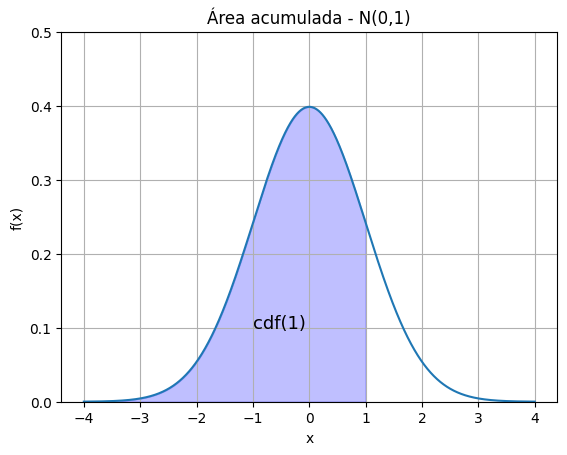

In [19]:
# - Área acumulada bajo la curva normal -
fig, ax = plt.subplots()
x_cdf = np.arange(-4, 4, 0.001)
ax.plot(x_cdf, norm.pdf(x_cdf))      # curva de la N(0,1)

# Sombreamos el área desde -4 hasta x=1 (cdf(1))
px_cdf = np.arange(-4, 1, 0.001)
ax.fill_between(px_cdf, norm.pdf(px_cdf), alpha=0.25, color='b')
ax.text(-1, 0.1, 'cdf(1)', fontsize=13)

ax.set_title('Área acumulada - N(0,1)')
ax.set_xlabel('x');  ax.set_ylabel('f(x)')
ax.set_ylim(0, 0.5);  ax.grid(True)
plt.show()

### Cálculo de probabilidades de una distribución normal


Calculemos $\text{cdf}(2)=\mathbb{P}(X\le2)$ cuando $X\sim N(3,2^2)$.


$$Z = \frac{X-\mu}{\sqrt{\sigma^2}} \sim N(0,1)$$


In [20]:
# P(X ≤ 2) para X ~ N(3, 2²)
# norm.cdf(x, loc=μ, scale=σ): F(x) = P(X ≤ x)
prob_norm1 = norm.cdf(x=2, loc=3, scale=2)
print(f'P(X ≤ 2) = {prob_norm1:.4f}')

P(X ≤ 2) = 0.3085


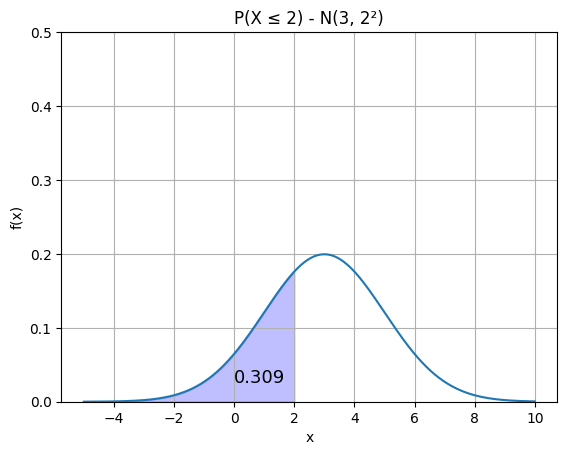

In [21]:
# Visualización de P(X ≤ 2) para N(3, 2²)
fig, ax = plt.subplots()
x_n1 = np.arange(-5, 10, 0.001)
ax.plot(x_n1, norm.pdf(x_n1, loc=3, scale=2))  # curva N(3,4)

# Sombreamos el área a la izquierda de x=2
px_n1 = np.arange(-5, 2, 0.001)
ax.fill_between(px_n1, norm.pdf(px_n1, loc=3, scale=2), alpha=0.25, color='b')
ax.text(0, 0.025, round(norm.cdf(x=2, loc=3, scale=2), 3), fontsize=13)

ax.set_title('P(X ≤ 2) - N(3, 2²)')
ax.set_xlabel('x');  ax.set_ylabel('f(x)')
ax.set_ylim(0, 0.5);  ax.grid(True)
plt.show()

Calculemos $\mathbb{P}(0.5<𝑋<2)$ cuando $X\sim N(1,2)$.


In [22]:
# P(0.5 < X < 2) para X ~ N(1, 2)
# Usando norm(loc, scale): instancia la distribución N(μ, σ)
s_n2 = np.sqrt(2)                              # desviación estándar (σ = √varianza)
prob_n2 = norm(1, s_n2).cdf(2) - norm(1, s_n2).cdf(0.5)  # P(a<X<b) = F(b)-F(a)
print(f'P(0.5 < X < 2) = {prob_n2:.4f}')

P(0.5 < X < 2) = 0.3984


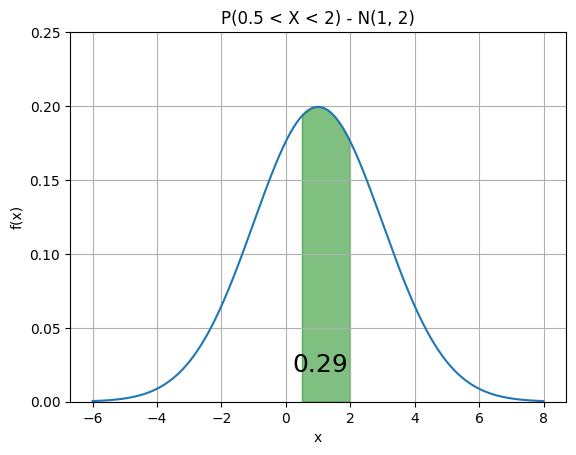

In [23]:
# Visualización de P(0.5 < X < 2) para N(1, √2²)
fig, ax = plt.subplots()
x_n2 = np.arange(-6, 8, 0.001)
ax.plot(x_n2, norm.pdf(x_n2, loc=1, scale=2))

# Sombreamos solo la franja entre 0.5 y 2
px_n2 = np.arange(0.5, 2, 0.01)
ax.fill_between(px_n2, norm.pdf(px_n2, loc=1, scale=2), alpha=0.5, color='g')
ax.text(0.2, 0.02, round(norm(1, 2).cdf(2) - norm(1, 2).cdf(0.5), 2), fontsize=18)

ax.set_title('P(0.5 < X < 2) - N(1, 2)')
ax.set_xlabel('x');  ax.set_ylabel('f(x)')
ax.set_ylim(0, 0.25);  ax.grid(True)
plt.show()

**Ejemplo importante** Si $Z\sim N(0,1)$, encuentra $\mathbb{P}(-1.93 < Z < 1.93)$. La probabilidad buscada es:


In [24]:
# P(-1.93 < Z < 1.93) para Z ~ N(0,1)
prob_z = norm(0, 1).cdf(1.93) - norm(0, 1).cdf(-1.93)
print(f'P(-1.93 < Z < 1.93) = {prob_z:.4f}')

P(-1.93 < Z < 1.93) = 0.9464


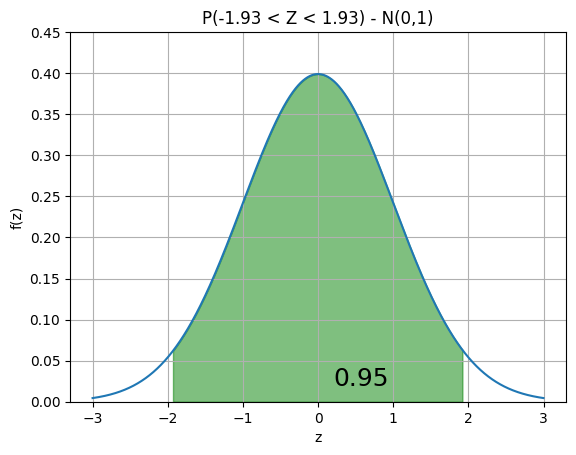

In [25]:
# Visualización del área P(-1.93 < Z < 1.93)
fig, ax = plt.subplots()
x_z = np.arange(-3, 3, 0.001)
ax.plot(x_z, norm.pdf(x_z))          # curva N(0,1)

# Sombreamos la región entre -1.93 y 1.93
px_z = np.arange(-1.93, 1.93, 0.01)
ax.fill_between(px_z, norm.pdf(px_z), alpha=0.5, color='g')
ax.text(0.2, 0.02, round(prob_z, 2), fontsize=18)

ax.set_title('P(-1.93 < Z < 1.93) - N(0,1)')
ax.set_xlabel('z');  ax.set_ylabel('f(z)')
ax.set_ylim(0, 0.45);  ax.grid(True)
plt.show()

### Cálculo de probabilidades:

$\mathbb{P}(0<Z<b)$: Queremos calcular $\mathbb{P}(0<Z<0.43)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(0<Z<0.43) = 0.1664$

$\mathbb{P}(-b<Z<b)$: Queremos calcular $\mathbb{P}(-0.16<Z<0.16)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(-0.16<Z<0.16) = \mathbb{P}(-0.16<Z<0)+\mathbb{P} (0<Z<0.16) = \mathbb{P}(0<Z<0.16)+\mathbb{P}(0<Z<0.16) = 2\mathbb{P}(0<Z<0.16) = 2(0.0636) = 0.1272$

$\mathbb{P}(Z<-b)$: Queremos calcular $\mathbb{P}(Z<-1.94)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(Z<-1.94) = \mathbb{P}(Z<0)+\mathbb{P}(-1.94<Z<0) = \mathbb{P}(Z<0) + \mathbb{P}(0<Z<1.94) = 0.5 - 0.4738 = 0.0262$

$\mathbb{P}(Z>-b)$: Queremos calcular $(Z>-0.07)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(Z>-0.07) = \mathbb{P}(-0.07<Z<0) + \mathbb{P}(Z>0) = \mathbb{P}(0<Z<0.07) + \mathbb{P}(Z>0) = 0.0279 + 0.5 = 0.5279$


## Variable aleatoria Gamma con parámetros $\alpha$ y $\lambda$.

La distribución gamma se obtiene al considerar el tiempo que transcurre entre cierto número de ocurrencias de eventos que ocurren aleatoriamente en el tiempo

La función gamma $\Gamma:(0,\infty)\to \mathbb{R}$ está definida como
$$\Gamma(\alpha)=\int_{0}^{\infty}t^{\alpha-1}e^{-t}dt.$$

_Propiedades de la función gamma_.

- $\Gamma(\alpha)<\infty$ para cualquier $\alpha>0$.
- $\Gamma(\alpha+1)=\alpha\Gamma(\alpha)$.
- Si $n\geq 1$ $\Gamma(n)=(n-1)!$
- $\Gamma\left(\frac{1}{2} \right)=\sqrt{\pi}$.

Si $\alpha$ y $\lambda$ son reales positivos, decimos que una variable aleatoria $X$ tiene distribución gamma con parámetros $\alpha$ y $\lambda$ si tiene por función de densidad:

$$
\displaystyle f_{X}(x)=\begin{cases}
	\displaystyle \frac{\lambda^{\alpha}x^{\alpha-1}e^{-\lambda x} }{\Gamma(\alpha)} & x>0\\
	0 & \text{en otro caso}
	\end{cases}
$$

En esta caso, escribimos la información anterior como $X\sim \Gamma(\alpha,\lambda) $

Donde $\alpha$ es el parámetro de forma:

- si $\alpha<1$, la densidad es alta cerca del cero, y luego decrece.
- Si $\alpha = 1$, es la exponencial
- Si $\alpha >1$, la curva tiene una moda y tiene forma de campana hacia la derecha.
  y $\lambda$ es el parametro de escala (como se estira o se encoge horizontalmente)

**Ejemplo 1.** Una computadora cuántica cuenta con un tipo de aparato de medición, el cual tiene un tiempo de vida que se distribuye exponencialmente, de tal manera que su tiempo promedio de vida es de $1000$ horas. Si se utilizan $10$ de estos aparatos en forma consecutiva, uno de ellos después de que el anterior ya no funciona. ¿Cuál es la probabilidad de que alguno de los aparatos estará funcionando después de $10,000$ horas?

**Solución.**
Sea $X$ el tiempo total de vida de los $10$ aparatos, usados, como se indica, uno después del otro. Entonces $X\sim \Gamma(10, 0.001)$. Así,
$$\mathbb{P}(X>10000)=\int_{10000}^{\infty}\frac{(0.001)^{10}}{9!}x^{9}e^{-0.001x}dx=0.4579.$$

**Ejemplo 2.** Consideremos un call center donde los tiempos entre llamadas son independientes y se distribuyen exponencialmente con una media de 3 minutos. Supongamos que queremos encontrar la probabilidad de que transcurran más de 30 minutos antes de recibir 10 llamadas.

**Solución.**
Sea $X$ el tiempo total para recibir $10$ llamadas. Dado que el tiempo medio entre llamadas es de $3$ minutos. Entonces $X \sim \Gamma(10, \frac{1}{3})$. Así
$$P(X > 30) = \int_{30}^{\infty} \frac{\left(\frac{1}{3}\right)^{10} x^{9} e^{-\frac{x}{3}}}{9!} \, dx = 0.45793.$$

La esperanza para una variable aleatoria $X\sim Γ(\alpha, \lambda)$ es:

$$
\mathbb{E}(X) = \frac{\alpha}{\lambda}
$$

y su varianza es:

$$
\text{Var}(X) = \frac{\alpha}{\lambda^2}
$$

La distribución gamma es esencial en varios campos por su capacidad para modelar tiempos de espera y eventos con tasas constantes. Sus aplicaciones incluyen:

- $\textbf{Teoría de colas y procesos estocásticos:}$ Modela el tiempo de espera hasta el k-ésimo evento.
- $\textbf{Confiabilidad y análisis de supervivencia:}$ Utilizada para tiempos de fallo y eventos críticos en medicina.
- $\textbf{Hidrología y meteorología:}$ Aplica en la modelación de precipitaciones acumuladas y tamaños de gotas.
- $\textbf{Procesamiento de imágenes y señales:}$ En el ajuste de modelos a datos de intensidades.
- $\textbf{Finanzas:}$ Para rendimientos de activos que no siguen distribuciones normales.
- $\textbf{Biología y ecología:}$ Para tasas de crecimiento y tiempos entre eventos biológicos.
- $\textbf{Física:}$ Describe tiempos de decaimiento y distribuciones de energía.


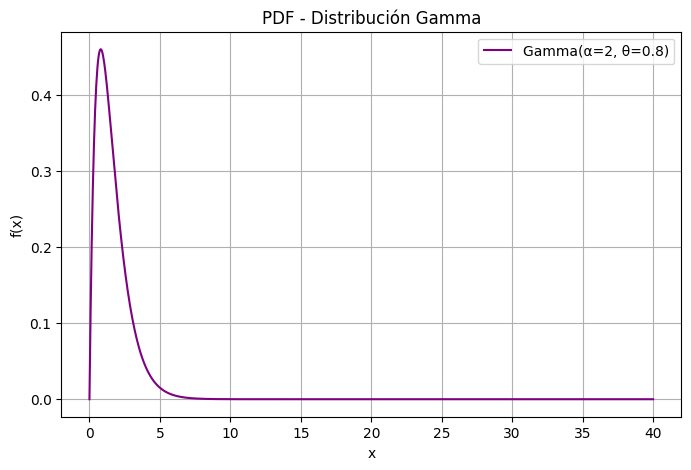

In [26]:
# - Gráfica de la distribución Gamma -
from scipy.stats import gamma

# En scipy: gamma(a=α, scale=1/λ)
shape = 2     # parámetro de forma α
scale = 0.8   # parámetro de escala (= 1/λ)

x_gam = np.linspace(0, 40, 1000)   # dominio positivo
pdf_gam = gamma.pdf(x_gam, a=shape, scale=scale)  # f(x; α, 1/λ)

plt.figure(figsize=(8, 5))
plt.plot(x_gam, pdf_gam, color='purple',
         label=f'Gamma(α={shape}, θ={scale})')
plt.xlabel('x');  plt.ylabel('f(x)')
plt.title('PDF - Distribución Gamma')
plt.grid(True);  plt.legend()
plt.show()

- Si $\alpha = 1$, $\lambda > 0 \Rightarrow$ v.a. exponencial.

- Si $\lambda = \frac{1}{2}$, $\alpha = \frac{k}{2}$, $k \in \mathbb{Z}^{+} \Rightarrow$ ji-cuadrada.

- Si $\lambda > 1$ y $\alpha > 1 \Rightarrow$ Erlang $\Rightarrow$ aplicaciones.


**Ejemplo** Sea $X \sim \mathcal{N}(0,1)$. Demostrar que $ X^2 $ tiene una distribución gamma.

**Solución:** Para $z \geq 0$, se tiene que:

$$
\begin{align*}
F_{X^2}(z) &= P(X^2 \leq z) = P(-\sqrt{z} \leq X \leq \sqrt{z}) \\
&= F_X(\sqrt{z}) - F_X(-\sqrt{z}) \\
\end{align*}
$$

Derivando, obtenemos la función de densidad:

$$ f*{X^2}(z) = \frac{d}{dz} F*{X^2}(z) = \frac{1}{2\sqrt{z}} f_X(\sqrt{z}) + \frac{1}{2\sqrt{z}} f_X(-\sqrt{z}) $$

Como la densidad de $X$ es simétrica, se tiene que

$$ f\_{X^2}(z) = \frac{1}{\sqrt{2\pi}} e^{-z/2} \frac{1}{2\sqrt{z}} = \frac{(1/2)^{1/2} z^{-1/2} e^{-z/2}}{\Gamma(1/2)} \sim Gamma\left(\frac{1}{2}, \frac{1}{2}\right) $$


## Variable aleatoria Beta con parámetros $\alpha$ y $\beta$.

La distribución beta es una familia de distribuciones de probabilidad continua definida en el intervalo [0, 1]. Es particularmente útil para modelar variables que representan proporciones y porcentajes.

La función beta, $B(\alpha, \beta)$, se define como:

$$
B(\alpha, \beta) = \int_0^1 t^{\alpha-1}(1-t)^{\beta-1} dt = \frac{\Gamma(\alpha) \Gamma(\beta)}{\Gamma(\alpha + \beta)}
$$

La función de densidad de probabilidad de la distribución beta se expresa como:

$$
f_X(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)},
$$

con $x\in (0,1)$.

**Notación.** $X\sim \text{Beta}(\alpha, \beta)$.

### Esperanza y Varianza
Si $X\sim \text{Beta}(\alpha, \beta)$, entonces
$$\mathbb{E}[X] = \frac{\alpha}{\alpha + \beta}$$
y
$$\text{Var}(X) = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}.$$

**Ejemplo.** Supongamos que un análisis sugiere que una nueva inversión tiene una alta probabilidad de éxito. Usando una distribución beta con $\alpha = 5$ y $\beta = 1$, entonces:

$$
f_{X}(x) = 5x^4, \quad \mathbb{E}[X] = \frac{5}{6}, \quad \text{Var}(X) = \frac{5}{252}
$$

**Aplicaciones en la Vida Real**

La distribución beta se utiliza en una variedad de campos, incluyendo:

- Finanzas: para modelar la variabilidad en tasas de retorno de inversiones.
- Mercadotecnia: para analizar proporciones de respuesta de consumidores.
- Ciencias de la salud: en la evaluación de la efectividad de tratamientos médicos.
- Ecología: para estimar proporciones en estudios de biodiversidad.
